adapted from https://github.com/LSSTDESC/transient-host-sims/blob/main/notebooks/SCOTCH_walkthroughs.ipynb
and https://github.com/LSSTDESC/transient-host-sims/blob/main/notebooks/pzflow_DC2_conditionalFlow_finalCut.ipynb
and https://jfcrenshaw.github.io/pzflow/tutorials/intro/

This notebook returns a pzflow model for SN Ia x1 and c distribution before selection effects based on the ZTF SN DR2 data. 
1. Train pzflow flow model using the x1, c and hostmass given in ZTF SN DR2.
2. Draw 100,000 random x1, c to obtain pdfs (we tested that x1, c are uncorrelated so we don't need a joint distribution).
3. Inverse-apply selection function to the pdfs in step 3. (pdf_before_selection=pdf_after_selection/selection_func) .
4. Draw 100,000 random x1, c from pdf_before_selection
5. Train another pzflow model conditioned on x1, c in step 4 (joint with hostmass).

In [1]:
# import jax
# jax.default_backend()
# import os
# os.environ["JAX_PLATFORM_NAME"] = "cpu"

In [2]:
import pandas as pd
import numpy as np
import pzflow
from pzflow import Flow
from pzflow.bijectors import Chain, ColorTransform, InvSoftplus, StandardScaler, RollingSplineCoupling
# from pzflow.examples import galaxy_data
from pzflow.distributions import Uniform, Joint, Normal
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats.sampling import NumericalInversePolynomial
from scipy.stats import gaussian_kde

In [3]:
n_sample = 100000

In [4]:
globalhostdata = pd.read_csv('ztfsniadr2/tables/globalhost_data.csv')
localhostdata = pd.read_csv('ztfsniadr2/tables/localhost_data.csv')
sndata = pd.read_csv('ztfsniadr2/tables/snia_data.csv')

In [5]:
globalhostdata.head()

,ztfname,ra_host,dec_host,mass,mass_err,restframe_gz,restframe_gz_err,d_dlr
0,ZTF17aadlxmv,127.448161,33.906468,10.424,0.116619,1.061697,0.018439,0.083759
1,ZTF18aaadqua,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ZTF18aaanzph,157.746954,23.788548,10.996,0.123223,1.351697,0.018439,1.698443
3,ZTF18aaapivw,102.564481,27.141323,8.515,0.103325,0.591697,0.046861,2.969719
4,ZTF18aaaqexr,175.776562,15.566957,10.774,0.117661,1.211697,0.018439,0.102694


In [6]:
localhostdata.head()

,ztfname,mass,mass_err,restframe_gz,restframe_gz_err
0,ZTF17aadlxmv,10.001,0.025,1.218697,0.017029
1,ZTF18aaadqua,6.743,0.344,0.321697,1.289935
2,ZTF18aaanzph,8.344,0.168,1.287697,0.500016
3,ZTF18aaapivw,7.507,0.092,0.607697,0.336146
4,ZTF18aaaqexr,10.727,0.065,1.313697,0.017692


In [7]:
sndata.head()

,Unnamed: 0,ztfname,redshift,redshift_err,source,t0,x0,x1,c,t0_err,...,mwebv_err,fitprob,ra,dec,sn_type,sub_type,lccoverage_flag,fitquality_flag,iau_name,frac_fitted
0,0,ZTF17aadlxmv,0.062019,0.000013,z_gal,58878.085277,0.001126,0.459966,0.062074,0.219280,...,0.0,0.178353,127.448018,33.906536,snia-cosmo,norm,1.0,1.0,2020adv,100.0
1,1,ZTF18aaadqua,0.078672,0.002807,z_snid,58130.778798,0.000845,4.999999,-0.392734,14.743977,...,0.0,0.127972,26.798708,18.798611,snia-pec,03fg,0.0,0.0,2018lq,100.0
2,2,ZTF18aaanzph,0.063718,0.000016,z_gal,58138.014461,0.000275,-1.224903,0.567260,8.873835,...,0.0,0.576895,157.743465,23.788356,snia-cosmo,norm,0.0,0.0,2018kc,100.0
3,3,ZTF18aaapivw,0.026341,0.004328,z_snid,58152.873526,0.001008,-4.999998,0.660968,0.971755,...,0.0,0.249074,102.563278,27.140073,snia-cosmo,norm,0.0,0.0,2018xi,100.0
4,4,ZTF18aaaqexr,0.070258,0.000022,z_gal,58893.687923,0.000610,-1.437246,0.048229,0.170907,...,0.0,0.038322,175.776516,15.567129,snia,NaN,1.0,1.0,2020chl,100.0


In [8]:
data = pd.merge(sndata,globalhostdata,on='ztfname')
data.head()

,Unnamed: 0,ztfname,redshift,redshift_err,source,t0,x0,x1,c,t0_err,...,fitquality_flag,iau_name,frac_fitted,ra_host,dec_host,mass,mass_err,restframe_gz,restframe_gz_err,d_dlr
0,0,ZTF17aadlxmv,0.062019,0.000013,z_gal,58878.085277,0.001126,0.459966,0.062074,0.219280,...,1.0,2020adv,100.0,127.448161,33.906468,10.424,0.116619,1.061697,0.018439,0.083759
1,1,ZTF18aaadqua,0.078672,0.002807,z_snid,58130.778798,0.000845,4.999999,-0.392734,14.743977,...,0.0,2018lq,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,ZTF18aaanzph,0.063718,0.000016,z_gal,58138.014461,0.000275,-1.224903,0.567260,8.873835,...,0.0,2018kc,100.0,157.746954,23.788548,10.996,0.123223,1.351697,0.018439,1.698443
3,3,ZTF18aaapivw,0.026341,0.004328,z_snid,58152.873526,0.001008,-4.999998,0.660968,0.971755,...,0.0,2018xi,100.0,102.564481,27.141323,8.515,0.103325,0.591697,0.046861,2.969719
4,4,ZTF18aaaqexr,0.070258,0.000022,z_gal,58893.687923,0.000610,-1.437246,0.048229,0.170907,...,1.0,2020chl,100.0,175.776562,15.566957,10.774,0.117661,1.211697,0.018439,0.102694


In [9]:
data.columns

Index(['Unnamed: 0', 'ztfname', 'redshift', 'redshift_err', 'source', 't0',
       'x0', 'x1', 'c', 't0_err', 'x0_err', 'x1_err', 'c_err', 'cov_t0_x0',
       'cov_t0_x1', 'cov_t0_c', 'cov_x0_x1', 'cov_x0_c', 'cov_x1_c', 'mwebv',
       'mwr_v', 'mwebv_err', 'fitprob', 'ra', 'dec', 'sn_type', 'sub_type',
       'lccoverage_flag', 'fitquality_flag', 'iau_name', 'frac_fitted',
       'ra_host', 'dec_host', 'mass', 'mass_err', 'restframe_gz',
       'restframe_gz_err', 'd_dlr'],
      dtype='object')

In [10]:
data_train = data[['mass','x1','c']]
data_train

,mass,x1,c
0,10.424,0.459966,0.062074
1,NaN,4.999999,-0.392734
2,10.996,-1.224903,0.567260
3,8.515,-4.999998,0.660968
4,10.774,-1.437246,0.048229
...,...,...,...
3623,10.620,-0.820927,-0.125119
3624,9.818,0.985630,0.088372
3625,10.378,5.000000,-0.352244
3626,10.728,-0.264331,0.199896


In [11]:
data_train = data_train.dropna()
data_train

,mass,x1,c
0,10.424,0.459966,0.062074
2,10.996,-1.224903,0.567260
3,8.515,-4.999998,0.660968
4,10.774,-1.437246,0.048229
6,9.870,4.999980,1.008026
...,...,...,...
3623,10.620,-0.820927,-0.125119
3624,9.818,0.985630,0.088372
3625,10.378,5.000000,-0.352244
3626,10.728,-0.264331,0.199896


In [12]:
flow = Flow(data_train.columns)

In [13]:
losses = flow.train(data_train, verbose=True)

Training 100 epochs 
Loss:
(0) 5.4856
(1) 4.8619
(6) 3.2136
(11) 2.8548
(16) 2.5374
(21) 2.4045
(26) 2.2826
(31) 2.2328
(36) 2.1949
(41) 2.1872
(46) 2.1887
(51) 2.1483
(56) 2.1459
(61) 2.1351
(66) 2.1122
(71) 2.1087
(76) 2.0975
(81) 2.0899
(86) 2.0901
(91) 2.0714
(96) 2.1086
(100) 2.0697


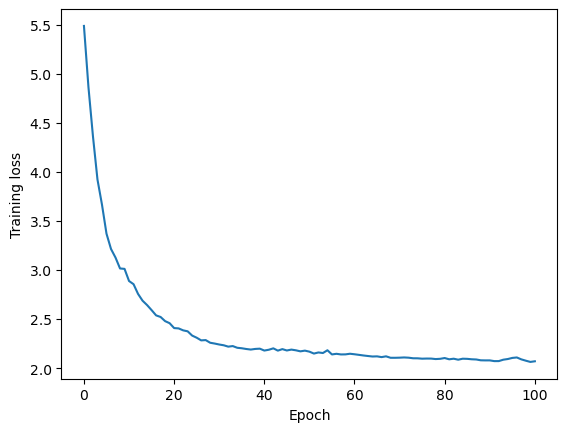

In [14]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.show()

In [15]:
flow.save("data/ztfsniadr2_host_sn_pzflow.pkl")

In [16]:
flow = Flow(file="data/ztfsniadr2_host_sn_pzflow.pkl")

In [17]:
samples = flow.sample(n_sample)

<Axes: >

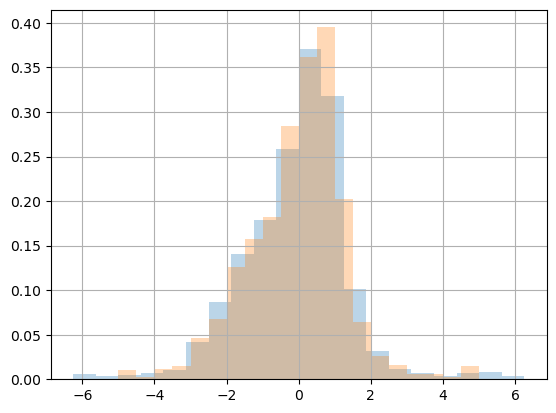

In [18]:
samples.x1.hist(bins=20,alpha=0.3,density=True)
data_train.x1.hist(bins=20,alpha=0.3,density=True)

<Axes: >

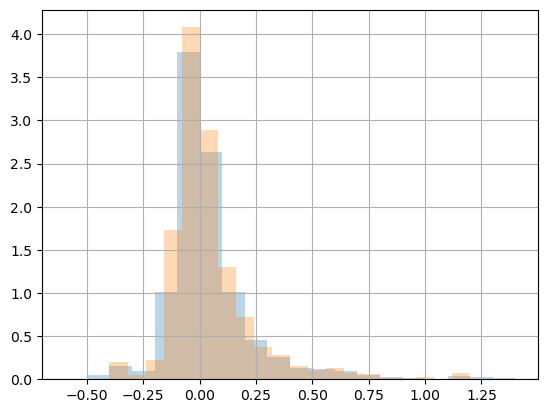

In [19]:
samples.c.hist(bins=20,alpha=0.3,density=True)
data_train.c.hist(bins=20,alpha=0.3,density=True)

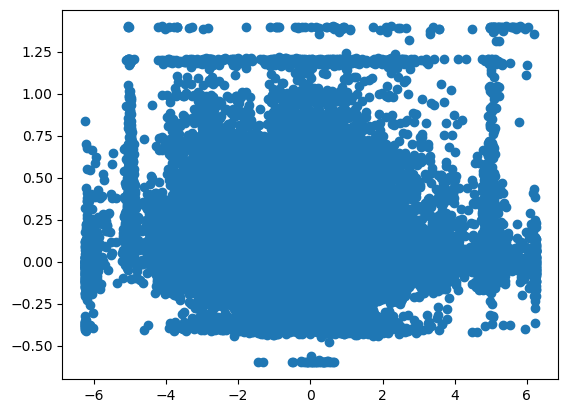

In [20]:
plt.scatter(samples['x1'],samples['c'])

In [21]:
cov = np.cov(samples['x1'],samples['c'])

In [22]:
cov

array([[ 2.09058245, -0.018434  ],
       [-0.018434  ,  0.04114648]])

In [23]:
def expo(x, a, b, c):
    x = np.asarray(x)
    y = a * np.exp(b * x) + c
    return y

In [24]:
# fx1_arr = np.loadtxt('data/ztf_selection_func_x1.txt')
# fc_arr = np.loadtxt('data/ztf_selection_func_c.txt')
fx1_parr = np.loadtxt('data/ztf_selection_func_x1.txt')
fc_parr = np.loadtxt('data/ztf_selection_func_c.txt')

In [25]:
fx1_func = lambda x1: expo(x1, *fx1_parr)
fc_func = lambda c: expo(c, *fc_parr)

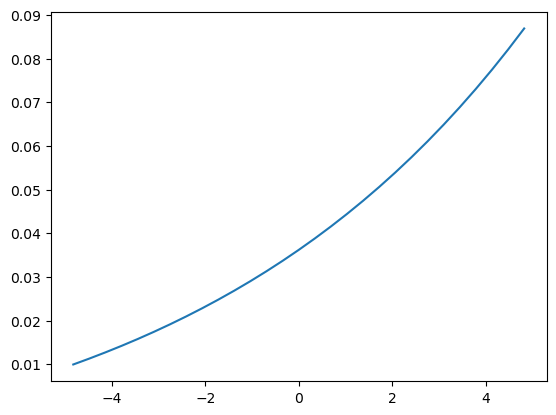

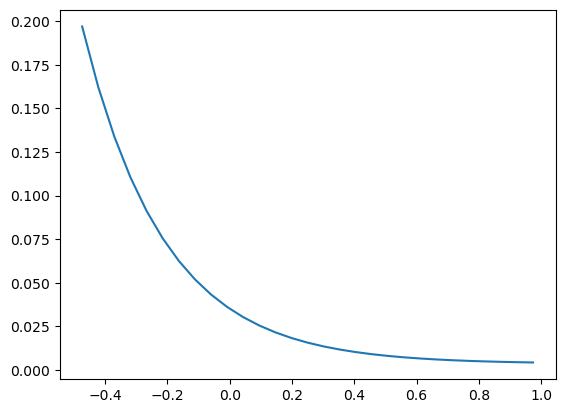

In [26]:
bins_x1 = np.linspace(-5, 5, 30)
bins_c = np.linspace(-0.5, 1, 30) 

binwidth_x1 = bins_x1[1]-bins_x1[0]
binwidth_c = bins_c[1]-bins_c[0]

x1_binned_pdf,x1_bin_edges = np.histogram(samples['x1'],bins=bins_x1)
c_binned_pdf,c_bin_edges = np.histogram(samples['c'],bins=bins_c)

x1_bin_center = (x1_bin_edges[1:] + x1_bin_edges[:-1])*0.5 
c_bin_center = (c_bin_edges[1:] + c_bin_edges[:-1])*0.5 

x1_pdf_orig = gaussian_kde(samples['x1'])
c_pdf_orig = gaussian_kde(samples['c'])

x1_pdf_modified = lambda x1: x1_pdf_orig(x1)/fx1_func(x1)
c_pdf_modified = lambda c: c_pdf_orig(c)/fc_func(c)

plt.plot(x1_bin_center, fx1_func(x1_bin_center))
plt.show()

plt.plot(c_bin_center, fc_func(c_bin_center))
plt.show()

In [27]:
# binwidth_x1 = fx1_arr[0][1]-fx1_arr[0][0]
# binwidth_c = fc_arr[0][1]-fc_arr[0][0]

# bins_x1 = np.append((fx1_arr[0]-0.5*binwidth_x1), fx1_arr[0][-1]+0.5*binwidth_x1)
# bins_c = np.append((fc_arr[0]-0.5*binwidth_c), fc_arr[0][-1]+0.5*binwidth_c)

# x1_binned_pdf,x1_bin_edges = np.histogram(samples['x1'],bins=bins_x1)
# c_binned_pdf,c_bin_edges = np.histogram(samples['c'],bins=bins_c)

# x1_binned_pdf_modified = x1_binned_pdf/fx1_arr[1]
# c_binned_pdf_modified = c_binned_pdf/fc_arr[1]

<BarContainer object of 29 artists>

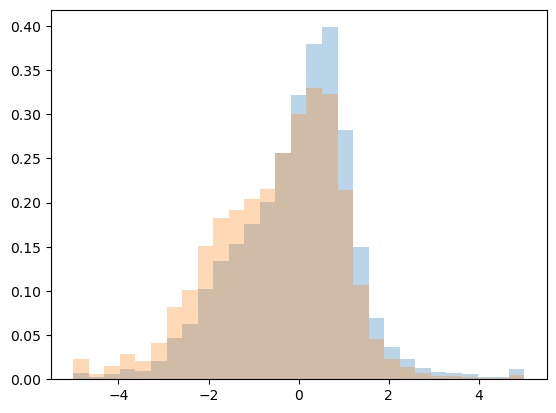

In [28]:
plt.bar(x1_bin_center,x1_pdf_orig(x1_bin_center)/np.sum(x1_pdf_orig(x1_bin_center))/binwidth_x1,alpha=0.3,width=binwidth_x1)
plt.bar(x1_bin_center,x1_pdf_modified(x1_bin_center)/np.sum(x1_pdf_modified(x1_bin_center))/binwidth_x1,alpha=0.3,width=binwidth_x1)

<BarContainer object of 29 artists>

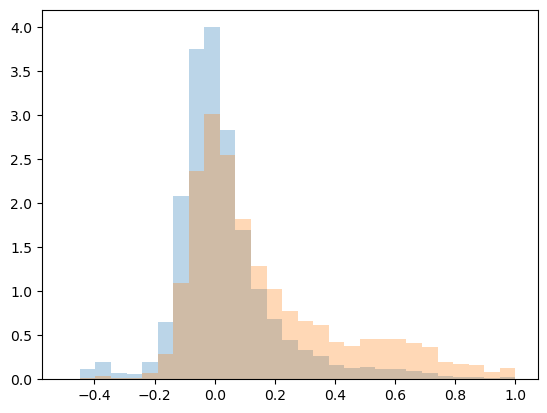

In [29]:
plt.bar(c_bin_center,c_pdf_orig(c_bin_center)/np.sum(c_pdf_orig(c_bin_center))/binwidth_c,alpha=0.3,width=binwidth_c)
plt.bar(c_bin_center,c_pdf_modified(c_bin_center)/np.sum(c_pdf_modified(c_bin_center))/binwidth_c,alpha=0.3,width=binwidth_c)

In [30]:
x1_pdf = interp1d(x1_bin_center,x1_pdf_modified(x1_bin_center)/np.sum(x1_pdf_modified(x1_bin_center))/binwidth_x1,fill_value=[0.],bounds_error=False)
c_pdf = interp1d(c_bin_center,c_pdf_modified(c_bin_center)/np.sum(c_pdf_modified(c_bin_center))/binwidth_c,fill_value=[0.],bounds_error=False)

In [31]:
# plt.bar(0.5*(c_bin_edges[:-1]+c_bin_edges[1:]),c_binned_pdf/np.sum(c_binned_pdf)/binwidth_c,alpha=0.3,width=binwidth_c)
# plt.bar(0.5*(c_bin_edges[:-1]+c_bin_edges[1:]),c_binned_pdf_modified/np.sum(c_binned_pdf_modified)/binwidth_c,alpha=0.3,width=binwidth_c)

In [32]:
# x1_pdf = interp1d(fx1_arr[0],x1_binned_pdf_modified,fill_value=[0.],bounds_error=False)
# c_pdf = interp1d(fc_arr[0],c_binned_pdf_modified,fill_value=[0.],bounds_error=False)

In [33]:
class x1distr:
   def pdf(self, x):
       return x1_pdf(x)

In [34]:
class cdistr:
   def pdf(self, x):
       return c_pdf(x)

In [35]:
urng = np.random.default_rng()

dist = x1distr()
rng = NumericalInversePolynomial(dist, random_state=urng)
x1 = rng.rvs(n_sample)

dist = cdistr()
rng = NumericalInversePolynomial(dist, random_state=urng)
c = rng.rvs(n_sample)

Training 100 epochs 
Loss:
(0) 2.1573
(1) 2.0241
(6) 1.6596
(11) 1.4402
(16) 1.2849
(21) 1.1976
(26) 1.1516
(31) 1.1413
(36) 1.1192
(41) 1.1070
(46) 1.0951
(51) 1.0966
(56) 1.0928
(61) 1.0859
(66) 1.0842
(71) 1.0946
(76) 1.0778
(81) 1.0719
(86) 1.0816
(91) 1.0727
(96) 1.0819
(100) 1.0678


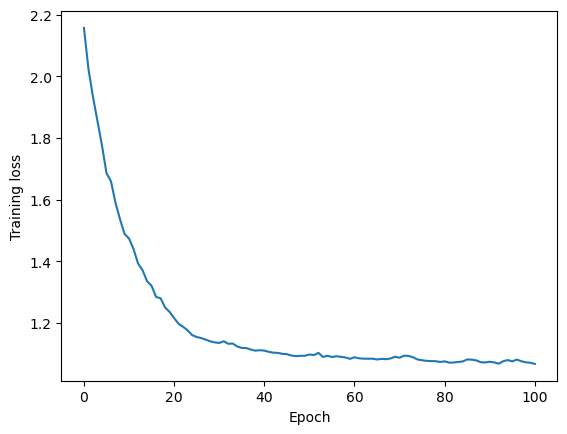

In [36]:
flow_cond = Flow(data_columns=["mass"], conditional_columns=["x1","c"])
losses = flow_cond.train(data_train, verbose=True)
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.show()

In [37]:
df = pd.DataFrame({"x1":x1,"c":c})
samples_cond = flow_cond.sample(1, conditions=df)

<Axes: >

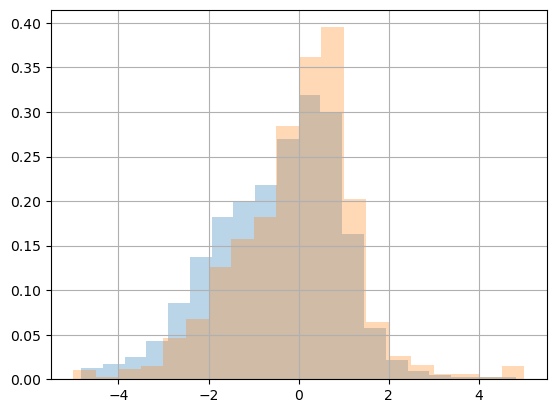

In [38]:
samples_cond.x1.hist(bins=20,alpha=0.3,density=True)
data_train.x1.hist(bins=20,alpha=0.3,density=True)

<Axes: >

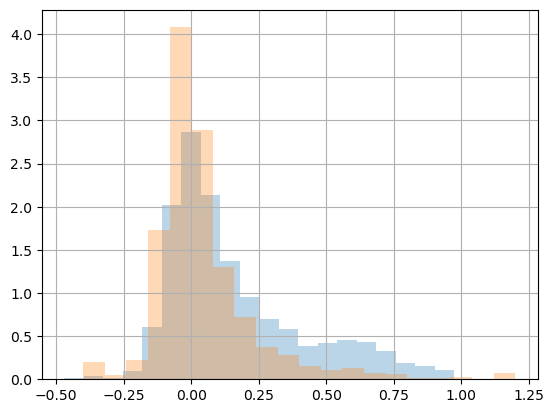

In [39]:
samples_cond.c.hist(bins=20,alpha=0.3,density=True)
data_train.c.hist(bins=20,alpha=0.3,density=True)

Training 100 epochs 
Loss:
(0) 5.6321
(1) 2.7013
(6) 2.5101
(11) 2.5092
(16) 2.5068
(21) 2.5011
(26) 2.4966
(31) 2.4979
(36) 2.4959
(41) 2.4927
(46) 2.4867
(51) 2.4892
(56) 2.4899
(61) 2.4847
(66) 2.4842
(71) 2.4829
(76) 2.4887
(81) 2.4833
(86) 2.4854
(91) 2.4806
(96) 2.4818
(100) 2.4819


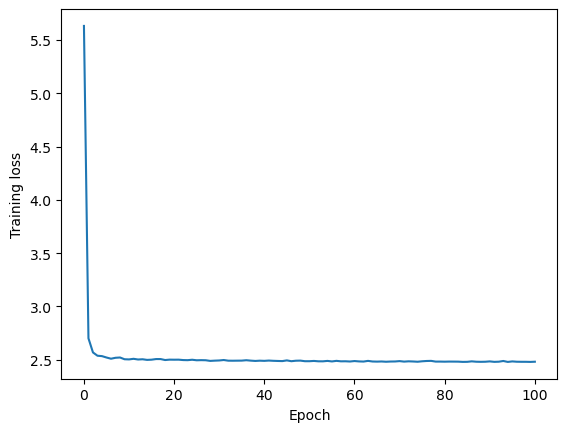

In [40]:
flow_before_selection = Flow(samples_cond.columns)
losses = flow_before_selection.train(samples_cond, verbose=True)
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.show()

In [41]:
flow_before_selection.save("data/ztfsniadr2_host_sn_before_selection_pzflow.pkl")

In [42]:
flow = Flow(file="data/ztfsniadr2_host_sn_before_selection_pzflow.pkl")

In [43]:
samples = flow.sample(1000)

<Axes: >

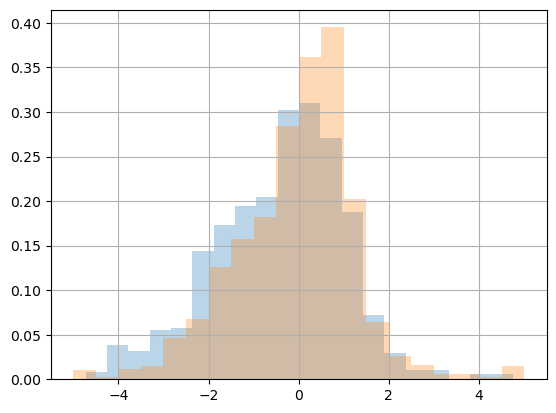

In [44]:
samples.x1.hist(bins=20,alpha=0.3,density=True)
data_train.x1.hist(bins=20,alpha=0.3,density=True)

<Axes: >

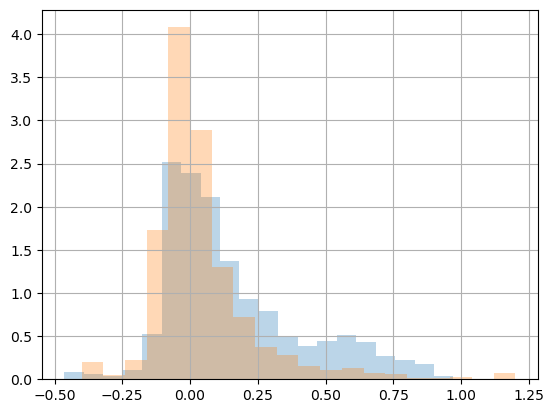

In [45]:
samples.c.hist(bins=20,alpha=0.3,density=True)
data_train.c.hist(bins=20,alpha=0.3,density=True)